# ResNet50 Multi-Label Classification for Dental Images

## Cell 1: Install Dependencies

In [1]:
# Install required packages
!pip install -q torch torchvision pillow scikit-learn matplotlib seaborn tqdm

import torch
import torchvision
import numpy as np
import os
from pathlib import Path
import shutil
import json
from datetime import datetime

print("✓ Dependencies installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ Dependencies installed
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## Cell 2: Mount Google Drive

In [2]:
# Mount Google Drive (ONLY for Colab users)
try:
    from google.colab import drive
    print("📂 Mounting Google Drive...")
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
    print("\nYour Drive location: /content/drive/MyDrive")
except:
    print("ℹ Not in Google Colab or Drive already mounted")

📂 Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive mounted

Your Drive location: /content/drive/MyDrive


## Cell 3: Configure Paths

In [3]:
# ===== CONFIGURATION =====
print("🔧 Configuring paths...\n")

DRIVE_PATH = "/content/drive/MyDrive"
PROJECT_FOLDER = "smart-dental-ai"
BASE_DIR = os.path.join(DRIVE_PATH, PROJECT_FOLDER)
DATASET_DIR = os.path.join(BASE_DIR, "datasets")
CLASSIFICATION_DATASET = os.path.join(DATASET_DIR, "classification-dataset")

OUTPUT_DIR = os.path.join(BASE_DIR, "runs/classification-results")
MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")

print(f"📁 Dataset folder: {CLASSIFICATION_DATASET}")
print(f"📁 Output: {OUTPUT_DIR}\n")

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

🔧 Configuring paths...

📁 Dataset folder: /content/drive/MyDrive/smart-dental-ai/datasets/classification-dataset
📁 Output: /content/drive/MyDrive/smart-dental-ai/runs/classification-results



## Cell 5: Multi-Label Dataset Class

In [5]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image as PILImage
import torch.nn as nn

print("📊 Setting up multi-label data loaders...\n")

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4

# ===== MULTI-LABEL DATASET =====
class MultiLabelDentalDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, labels_json=None):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.transform = transform
        self.samples = []

        # Load optional multi-label map
        multi_label_map = {}
        if labels_json and os.path.exists(labels_json):
            with open(labels_json, 'r') as f:
                raw = json.load(f)
            # Map filename -> list of class names
            multi_label_map = {k: v for k, v in raw.items()}
            print(f"✓ Loaded multi-label annotations: {len(multi_label_map)} entries")
        else:
            print("ℹ No labels.json found — using folder name as single label")

        # Walk through class folders
        for class_name in classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                if not os.path.isfile(fpath):
                    continue

                # Build label vector
                label_vec = torch.zeros(len(classes), dtype=torch.float32)

                if fname in multi_label_map:
                    for cname in multi_label_map[fname]:
                        if cname in self.class_to_idx:
                            label_vec[self.class_to_idx[cname]] = 1.0
                else:
                    # Default: single label from folder
                    label_vec[self.class_to_idx[class_name]] = 1.0

                self.samples.append((fpath, label_vec))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_vec = self.samples[idx]
        image = PILImage.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label_vec


# ===== TRANSFORMS =====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_path = os.path.join(CLASSIFICATION_DATASET, 'train')
val_path = os.path.join(CLASSIFICATION_DATASET, 'val')

# Get class list
classes = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
num_classes = len(classes)
print(f"\nClasses ({num_classes}): {classes}")

# Optional: point to a labels.json if you have multi-label annotations
train_labels_json = os.path.join(CLASSIFICATION_DATASET, 'train_labels.json')
val_labels_json = os.path.join(CLASSIFICATION_DATASET, 'val_labels.json')

train_dataset = MultiLabelDentalDataset(train_path, classes, train_transform, train_labels_json)
val_dataset = MultiLabelDentalDataset(val_path, classes, val_transform, val_labels_json)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✓ Data loaders created")
print(f"  Training samples : {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")

# Quick sanity check — show label vector for first sample
img, lbl = train_dataset[0]
print(f"\n  Example label vector: {lbl.tolist()}")
print(f"  Active conditions  : {[classes[i] for i, v in enumerate(lbl) if v == 1.0]}")

📊 Setting up multi-label data loaders...


Classes (6): ['Calculus', 'Caries', 'Discoloration', 'Gingivitis', 'Hypodontia', 'Ulcer']
ℹ No labels.json found — using folder name as single label
ℹ No labels.json found — using folder name as single label


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



✓ Data loaders created
  Training samples : 9288
  Validation samples: 2326

  Example label vector: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  Active conditions  : ['Calculus']


## Cell 6: Load ResNet50 — Multi-Label Head

In [6]:
from torchvision.models import resnet50, ResNet50_Weights

print("🔧 Loading ResNet50 model...\n")

weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

print("✓ ResNet50 loaded with ImageNet pretrained weights")

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False
print("✓ Backbone frozen")

# Replace head — NO softmax, NO sigmoid here (BCEWithLogitsLoss handles it)
model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, num_classes)  # Raw logits output
)

print(f"✓ Multi-label head replaced (output: {num_classes} raw logits)")

for param in model.fc.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

🔧 Loading ResNet50 model...

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


✓ ResNet50 loaded with ImageNet pretrained weights
✓ Backbone frozen
✓ Multi-label head replaced (output: 6 raw logits)

📊 Total parameters    : 24,623,558
   Trainable parameters: 1,115,526


## Cell 7: Training Loop (BCEWithLogitsLoss)

In [7]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import time

print("🚀 Starting Multi-Label Training\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

NUM_EPOCHS = 15
THRESHOLD = 0.5
best_val_loss = float('inf')
best_model_path = os.path.join(MODEL_SAVE_DIR, 'best_model.pth')

training_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

def multilabel_accuracy(preds_logits, targets, threshold=THRESHOLD):
    preds = (torch.sigmoid(preds_logits) > threshold).float()
    correct = (preds == targets).all(dim=1).float().mean()
    return correct.item() * 100

def train_epoch():
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    pbar = tqdm(train_loader, desc="Training", leave=False)
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += multilabel_accuracy(outputs, labels)
        pbar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}',
                          'Acc': f'{running_acc/(batch_idx+1):.2f}%'})

    return running_loss / len(train_loader), running_acc / len(train_loader)

def validate_epoch():
    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validating", leave=False)
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            running_acc += multilabel_accuracy(outputs, labels)

    return running_loss / len(val_loader), running_acc / len(val_loader)

# ===== TRAINING LOOP =====
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch()
    val_loss, val_acc = validate_epoch()
    scheduler.step(val_loss)
    elapsed = time.time() - t0

    training_history['train_loss'].append(train_loss)
    training_history['train_acc'].append(train_acc)
    training_history['val_loss'].append(val_loss)
    training_history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")

print(f"\n✅ Training complete. Best Val Loss: {best_val_loss:.4f}")

🚀 Starting Multi-Label Training



Training:   0%|          | 0/581 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [01/15] Train Loss: 0.3402 Acc: 26.85% | Val Loss: 0.2225 Acc: 52.83% | Time: 1793.4s
  ✓ Best model saved (val_loss: 0.2225)


Epoch [02/15] Train Loss: 0.2787 Acc: 45.75% | Val Loss: 0.2208 Acc: 60.89% | Time: 100.6s
  ✓ Best model saved (val_loss: 0.2208)


Epoch [03/15] Train Loss: 0.2632 Acc: 51.45% | Val Loss: 0.2063 Acc: 64.13% | Time: 98.9s
  ✓ Best model saved (val_loss: 0.2063)


...

Epoch [11/15] Train Loss: 0.2271 Acc: 59.67% | Val Loss: 0.1737 Acc: 70.93% | Time: 100.3s


Epoch [12/15] Train Loss: 0.2299 Acc: 58.95% | Val Loss: 0.1678 Acc: 69.56% | Time: 96.8s


Epoch [13/15] Train Loss: 0.2255 Acc: 60.70% | Val Loss: 0.1690 Acc: 70.63% | Time: 98.3s


Epoch [14/15] Train Loss: 0.2264 Acc: 60.63% | Val Loss: 0.1798 Acc: 66.99% | Time: 100.9s


Epoch [15/15] Train Loss: 0.2141 Acc: 62.37% | Val Loss: 0.1710 Acc: 63.78% | Time: 99.0s

✅ Training complete. Best Val Loss: 0.1675


## Cell 7b: Enhanced Training — Focal Loss + Fine-tuning (Optional)

> Use this to improve accuracy after the initial run above. Unfreezes backbone and uses multi-label Focal Loss.

In [ ]:
print("🚀 Enhanced Training: Multi-Label Focal Loss + Fine-tuning\n")

# Load best model from Phase 1
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    print(f"✓ Loaded best model from Phase 1: {best_model_path}")
    print(f"  File size: {os.path.getsize(best_model_path) / 1e6:.2f} MB")
    print(f"  Previous best val_loss: {best_val_loss:.4f}\n")
else:
    print(f"⚠️  WARNING: best_model.pth not found at {best_model_path}")
    print(f"  Training will continue with current model weights (Phase 1 end epoch)\n")

# ===== MULTI-LABEL FOCAL LOSS =====
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, pos_weight=self.pos_weight, reduction='none')
        p_t = torch.exp(-bce)
        loss = (1 - p_t) ** self.gamma * bce
        return loss.mean()

# ===== CLASS WEIGHTS FOR IMBALANCE =====
print("📊 Computing class weights...\n")
class_counts = {}
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
    class_counts[class_name] = count

total_samples = sum(class_counts.values())
pos_weights = []
for class_name in classes:
    neg = total_samples - class_counts[class_name]
    pos = class_counts[class_name]
    pos_weights.append(neg / pos)
    print(f"  {class_name:15} count={pos:5}  pos_weight={neg/pos:.2f}")

pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)

# ===== ENHANCED AUGMENTATION =====
enhanced_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.6),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=25),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_enhanced = MultiLabelDentalDataset(train_path, classes, enhanced_train_transform, train_labels_json)
train_loader_enhanced = DataLoader(train_dataset_enhanced, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=NUM_WORKERS, pin_memory=True)

# ===== UNFREEZE BACKBONE for fine-tuning =====
for param in model.parameters():
    param.requires_grad = True
print("\n✓ Backbone unfrozen for fine-tuning")

criterion_focal = MultiLabelFocalLoss(gamma=2.0, pos_weight=pos_weight_tensor)
optimizer_ft = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=3)  # mode='max' for accuracy

FT_EPOCHS = 20
TOTAL_EPOCHS = NUM_EPOCHS + FT_EPOCHS
EARLY_STOPPING_PATIENCE = 7  # Stop if no improvement for 5 epochs

# Get best accuracy from Phase 1
phase1_best_acc = max(training_history['val_acc']) if training_history['val_acc'] else 0.0
phase1_best_epoch = training_history['val_acc'].index(phase1_best_acc) + 1 if training_history['val_acc'] else 0

print(f"📌 Enhanced Training Configuration:")
print(f"   Phase 1 completed: {NUM_EPOCHS} epochs")
print(f"   Phase 1 best accuracy: {phase1_best_acc:.2f}% (Epoch {phase1_best_epoch})")
print(f"   Phase 2 will run: {FT_EPOCHS} additional epochs (max)")
print(f"   Early stopping patience: {EARLY_STOPPING_PATIENCE} epochs")

# Track fine-tuning history
ft_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_ft_val_acc = 0.0  # ← Track BEST ACCURACY, not loss
patience_counter = 0

for epoch in range(1, FT_EPOCHS + 1):
    current_total_epoch = NUM_EPOCHS + epoch
    model.train()
    running_loss, running_acc = 0.0, 0.0
    pbar = tqdm(train_loader_enhanced, desc=f"FT Epoch {epoch}", leave=False)
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        outputs = model(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer_ft.step()
        running_loss += loss.item()
        running_acc += multilabel_accuracy(outputs, labels)

    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc="Validating", leave=False)
        for batch_idx, (images, labels) in enumerate(pbar_val):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion_focal(outputs, labels).item()
            val_acc += multilabel_accuracy(outputs, labels)

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    # Store history
    train_loss_avg = running_loss/len(train_loader_enhanced)
    train_acc_avg = running_acc/len(train_loader_enhanced)
    ft_history['train_loss'].append(train_loss_avg)
    ft_history['train_acc'].append(train_acc_avg)
    ft_history['val_loss'].append(val_loss)
    ft_history['val_acc'].append(val_acc)

    scheduler_ft.step(val_acc)  # ← Step scheduler based on accuracy

    print(f"Epoch [{current_total_epoch:02d}/{TOTAL_EPOCHS}] (FT {epoch:02d}/{FT_EPOCHS}) "
          f"Train Loss: {train_loss_avg:.4f} Acc: {train_acc_avg:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    # Early stopping check — based on ACCURACY, not loss
    if val_acc > best_ft_val_acc:
        best_ft_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        improvement = val_acc - phase1_best_acc
        if improvement > 0:
            print(f"  ✓ Best model saved (Acc: {val_acc:.2f}%) | +{improvement:.2f}% vs Phase 1 ✓")
        else:
            print(f"  ✓ Best model saved (Acc: {val_acc:.2f}%) | {improvement:.2f}% vs Phase 1")
    else:
        patience_counter += 1
        print(f"  ⚠ No accuracy improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early stopping triggered at Epoch {epoch}/{FT_EPOCHS}")
            print(f"   No accuracy improvement for {EARLY_STOPPING_PATIENCE} consecutive epochs")
            print(f"   Restoring best model (Acc: {best_ft_val_acc:.2f}%)...\n")
            model.load_state_dict(torch.load(best_model_path))
            break

# Get final best accuracy from Phase 2
phase2_best_acc = max(ft_history['val_acc']) if ft_history['val_acc'] else 0.0
phase2_best_epoch = ft_history['val_acc'].index(phase2_best_acc) + 1 if ft_history['val_acc'] else 0

print(f"\n✅ Fine-tuning complete. (Stopped at FT Epoch {epoch}/{FT_EPOCHS})")
print(f"\n📊 Training Summary:")
print(f"   Phase 1 Best Accuracy: {phase1_best_acc:.2f}% (Epoch {phase1_best_epoch})")
print(f"   Phase 2 Best Accuracy: {phase2_best_acc:.2f}% (FT Epoch {phase2_best_epoch})")
overall_improvement = phase2_best_acc - phase1_best_acc
if overall_improvement > 0:
    print(f"   Overall Improvement: +{overall_improvement:.2f}% ✓")
elif overall_improvement < 0:
    print(f"   Overall Change: {overall_improvement:.2f}%")
else:
    print(f"   No change in accuracy")

## Cell 8: Plot Training History

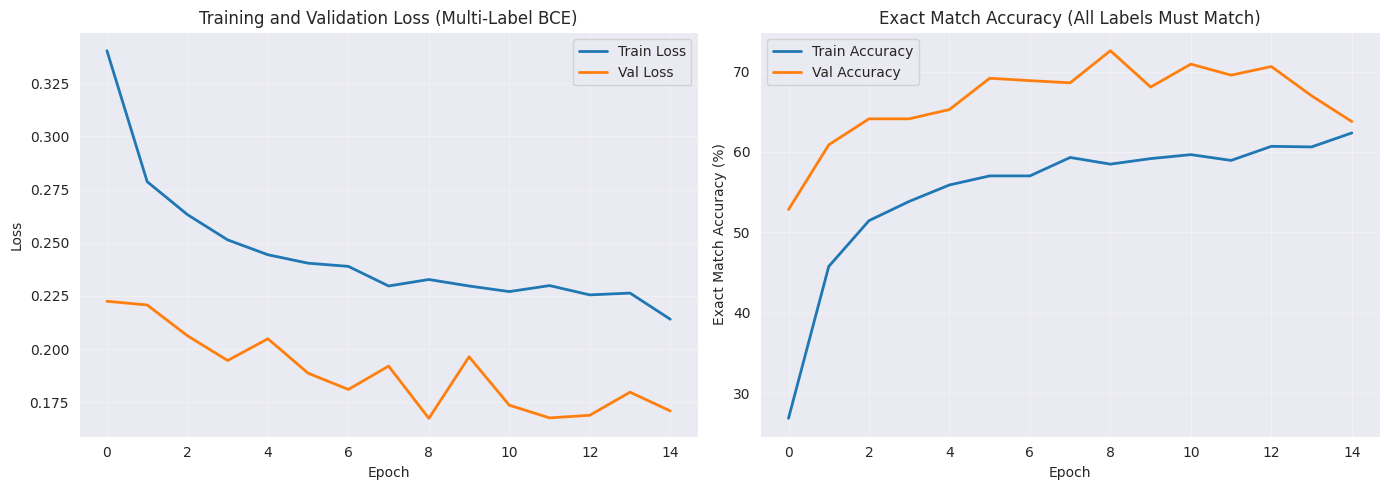

✓ Plot saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/training_history.png


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(training_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(training_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss (Multi-Label BCE)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(training_history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(training_history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Exact Match Accuracy (%)')
axes[1].set_title('Exact Match Accuracy (All Labels Must Match)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot saved to: {os.path.join(OUTPUT_DIR, 'training_history.png')}")

## Cell 9: Final Evaluation — Per-Class Metrics

In [27]:
from sklearn.metrics import classification_report
import numpy as np

print("📊 Final Multi-Label Evaluation\n")

model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > THRESHOLD).float()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

print("Per-Class Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

# Per-class accuracy
print("\nPer-Class Stats:")
for i, cls in enumerate(classes):
    tp = ((all_preds[:, i] == 1) & (all_labels[:, i] == 1)).sum()
    fp = ((all_preds[:, i] == 1) & (all_labels[:, i] == 0)).sum()
    fn = ((all_preds[:, i] == 0) & (all_labels[:, i] == 1)).sum()
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    print(f"  {cls:15} Precision: {precision:.2f}  Recall: {recall:.2f}  TP: {tp}  FP: {fp}  FN: {fn}")

📊 Final Multi-Label Evaluation

Per-Class Classification Report:
               precision    recall  f1-score   support

     Calculus       0.63      0.98      0.77       260
       Caries       0.92      1.00      0.96       469
Discoloration       0.97      0.99      0.98       367
   Gingivitis       0.74      0.98      0.84       470
   Hypodontia       0.87      0.98      0.92       251
        Ulcer       1.00      1.00      1.00       509

    micro avg       0.85      0.99      0.92      2326
    macro avg       0.85      0.99      0.91      2326
 weighted avg       0.87      0.99      0.92      2326
  samples avg       0.91      0.99      0.94      2326


Per-Class Stats:
  Calculus        Precision: 0.63  Recall: 0.98  TP: 254  FP: 148  FN: 6
  Caries          Precision: 0.92  Recall: 1.00  TP: 468  FP: 43  FN: 1
  Discoloration   Precision: 0.97  Recall: 0.99  TP: 364  FP: 11  FN: 3
  Gingivitis      Precision: 0.74  Recall: 0.98  TP: 460  FP: 163  FN: 10
  Hypodontia      

## Cell 10: Inference — Probabilities per Condition + Binary Decisions

🧪 Simplified Multi-Label Inference

INFERENCE FUNCTIONS READY

📌 Available Functions:

1️⃣  Single Image Prediction:
    results = predict_single('path/to/image.jpg', threshold=0.5)

2️⃣  Batch Prediction:
    results = predict_batch(['img1.jpg', 'img2.jpg'], threshold=0.5)


📸 Demo: 9 Random Validation Images



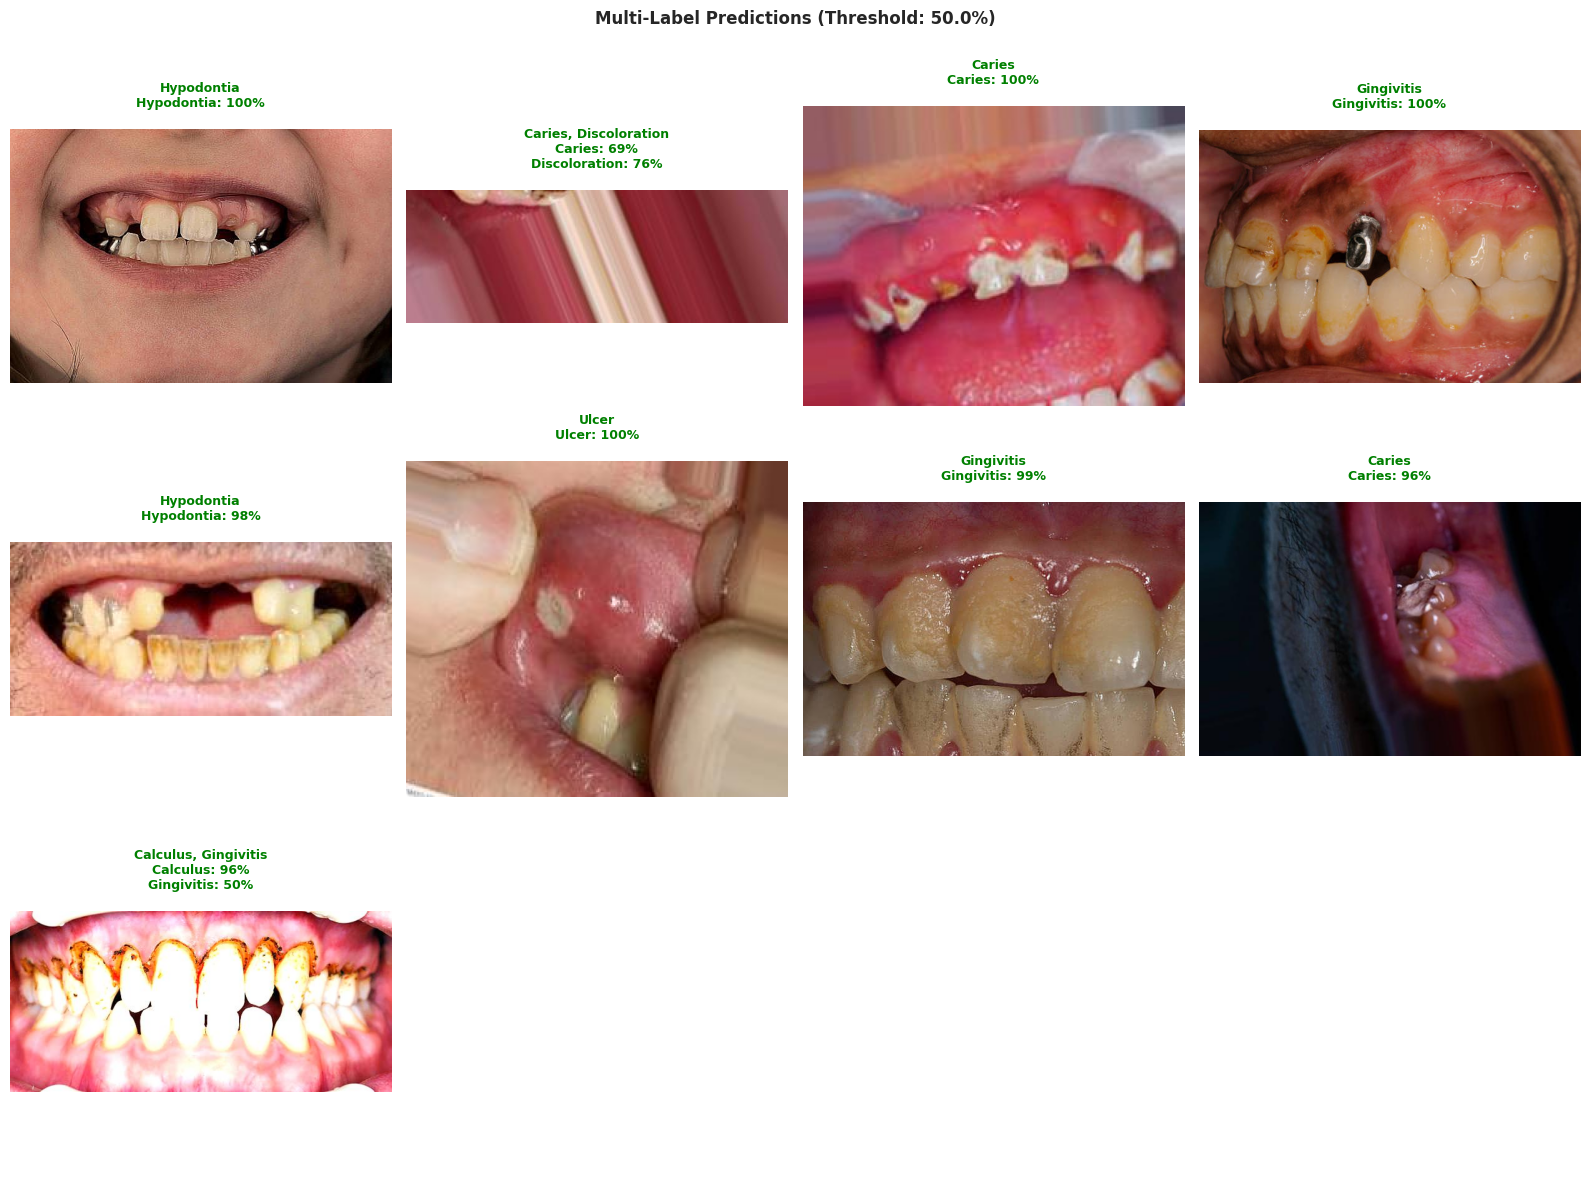

✓ Batch visualization saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/inference_batch.png


In [28]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt

print("🧪 Simplified Multi-Label Inference\n")

THRESHOLD = 0.5  # Default threshold

def predict_single(image_path, threshold=0.5, verbose=True):
    image = PILImage.open(image_path).convert('RGB')
    tensor = val_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    results = {cls: float(probs[i]) for i, cls in enumerate(classes)}

    if verbose:
        detected = [cls for cls, prob in results.items() if prob > threshold]
        print(f"🦷 Prediction Results:\n")
        print(f"{'Condition':<18} {'Probability':<15} {'Status'}")
        print("-" * 50)
        for cls, prob in sorted(results.items(), key=lambda x: x[1], reverse=True):
            status = "✅ DETECTED" if prob > threshold else "❌ Not Detected"
            bar = "█" * int(prob * 15) + "░" * (15 - int(prob * 15))
            print(f"{cls:<18} {prob:.1%}  [{bar}]  {status}")
        print("-" * 50)
        print(f"\n📋 Detected Conditions: {', '.join(detected) if detected else 'None'}\n")

    return results


def predict_batch(image_paths, threshold=0.5, show_images=True):
    num_images = len(image_paths)
    cols = 4
    rows = (num_images + cols - 1) // cols

    if show_images:
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        if num_images == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

    all_results = []

    for idx, img_path in enumerate(image_paths):
        image = PILImage.open(img_path).convert('RGB')
        tensor = val_transform(image).unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            logits = model(tensor)
            probs = torch.sigmoid(logits)[0].cpu().numpy()

        detected = [cls for i, cls in enumerate(classes) if probs[i] > threshold]
        results = {cls: float(probs[i]) for i, cls in enumerate(classes)}
        all_results.append({'detected': detected, 'probs': results})

        if show_images:
            ax = axes[idx]
            ax.imshow(image)
            ax.axis('off')

            # Title with detected conditions
            detected_str = ", ".join(detected) if detected else "No conditions"
            title = f"{detected_str}\n"

            # Add confidence scores for detected conditions
            for cls in detected:
                title += f"{cls}: {results[cls]:.0%}\n"

            color = 'green' if detected else 'gray'
            ax.set_title(title, fontsize=9, color=color, fontweight='bold', pad=5)

    # Hide unused subplots
    if show_images:
        for idx in range(num_images, len(axes)):
            axes[idx].axis('off')

        plt.suptitle(f'Multi-Label Predictions (Threshold: {threshold:.1%})',
                     fontsize=12, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'inference_batch.png'), dpi=150, bbox_inches='tight')
        plt.show()

    return all_results


print("=" * 60)
print("INFERENCE FUNCTIONS READY")
print("=" * 60)
print(f"\n📌 Available Functions:\n")
print("1️⃣  Single Image Prediction:")
print("    results = predict_single('path/to/image.jpg', threshold=0.5)\n")
print("2️⃣  Batch Prediction:")
print("    results = predict_batch(['img1.jpg', 'img2.jpg'], threshold=0.5)\n")
print("=" * 60)

# ===== QUICK DEMO: 9 random validation images =====
import random
print("\n📸 Demo: 9 Random Validation Images\n")
demo_samples = random.sample(val_dataset.samples, min(9, len(val_dataset.samples)))
demo_paths = [path for path, _ in demo_samples]
predict_batch(demo_paths, threshold=THRESHOLD, show_images=True)

print(f"✓ Batch visualization saved to: {os.path.join(OUTPUT_DIR, 'inference_batch.png')}")

## Cell 11: Save Model

In [19]:
print("💾 Saving multi-label model\n")

final_model_path = os.path.join(MODEL_SAVE_DIR, 'resnet50_multilabel_dental.pth')
torch.save(model.state_dict(), final_model_path)
print(f"✓ Model weights saved: {final_model_path}")

torch.save(model, os.path.join(MODEL_SAVE_DIR, 'resnet50_multilabel_dental_full.pth'))
print(f"✓ Full model saved")

metadata = {
    'model': 'ResNet50',
    'task': 'multi-label classification',
    'num_classes': num_classes,
    'classes': classes,
    'image_size': IMG_SIZE,
    'threshold': THRESHOLD,
    'loss': 'BCEWithLogitsLoss',
    'best_val_loss': best_val_loss,
    'training_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'timestamp': datetime.now().isoformat()
}

meta_file = os.path.join(MODEL_SAVE_DIR, 'model_metadata.json')
with open(meta_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved: {meta_file}")
print(f"\n📦 Files saved to: {MODEL_SAVE_DIR}")
print(f"  - resnet50_multilabel_dental.pth")
print(f"  - resnet50_multilabel_dental_full.pth")
print(f"  - model_metadata.json")

💾 Saving multi-label model

✓ Model weights saved: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models/resnet50_multilabel_dental.pth
✓ Full model saved
✓ Metadata saved: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models/model_metadata.json

📦 Files saved to: /content/drive/MyDrive/smart-dental-ai/runs/classification-results/models
  - resnet50_multilabel_dental.pth
  - resnet50_multilabel_dental_full.pth
  - model_metadata.json
